# 01 -- Load + Harmonize + Clean

For every raw file:
1. **Load** only the needed columns (`read_run`).
2. **Harmonize** -- resolve drifting Simulink column names, convert units so
   every run speaks the same physical unit (`harmonize`).
3. **De-duplicate** -- drop exact duplicate rows and duplicate timestamps
   (data-hygiene step; does not change the modelling method).
4. **Sanitize** -- physically impossible values (negative pressure/flow/fuel --
   `0` is a physics fact, not a tuned number) are flagged and treated as
   missing, then filled by the same interpolation used for missing data.
5. **Resample** onto one uniform time grid (`resample_uniform`).
6. **Outlier-clip** with a Hampel filter (`clean_run`).

Same methodology as before -- steps 3-4 are new hygiene checks, not pipeline
changes. Everything is cached to `artifacts/` so later notebooks don't
re-touch the ~230 MB raw files.

In [3]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
%matplotlib inline
import pdm_common as P

from pathlib import Path
P.RAW_DIR = Path(r"E:\DRDO\Sarthak Dhaigude_DRDO\PdM-main\RAW_DIR\raw")

import numpy as np, pandas as pd, json


In [4]:
frames, availability, dup_report, invalid_report = [], [], [], []

for fname, spec in P.FILE_MAP.items():
    path = P.RAW_DIR / fname
    if not path.exists():
        print(f"  !! missing {fname} -- skipped"); continue

    h = P.harmonize(P.read_run(path, spec), spec)
    h, n_dup_rows, n_dup_times = P.dedup_run(h)
    h, invalid_counts = P.sanitize_invalid(h)
    clean = P.clean_run(P.resample_uniform(h))

    have = [c for c in P.CANON if c in clean.columns and clean[c].notna().any()]
    availability.append(dict(run_id=path.stem, file=fname, label=spec["label"],
                             always_on=spec["always_on"], n_rows=len(clean),
                             t_max=float(h["time"].max()) if len(h) else np.nan,
                             signals="|".join(have)))
    dup_report.append(dict(file=fname, duplicate_rows=n_dup_rows,
                           duplicate_timestamps=n_dup_times))
    if any(invalid_counts.values()):
        invalid_report.append(dict(file=fname, **invalid_counts))

    clean = clean.assign(run_id=path.stem, label=spec["label"], always_on=spec["always_on"])
    frames.append(clean)

clean_all = pd.concat(frames, ignore_index=True)
print(f"Loaded {len(frames)} runs, {len(clean_all)} total clean rows.")

Loaded 13 runs, 34269 total clean rows.


## Duplicate-row / duplicate-timestamp report

In [5]:
dup_df = pd.DataFrame(dup_report)
n_total_dups = dup_df[["duplicate_rows", "duplicate_timestamps"]].to_numpy().sum()
print("No duplicate rows or timestamps found." if n_total_dups == 0
      else f"{n_total_dups} duplicate value(s) found and removed -- see table.")
dup_df

290144 duplicate value(s) found and removed -- see table.


,file,duplicate_rows,duplicate_timestamps
0,Healthy Data 3.xlsx,0,0
1,disp1_fault(0.5).xlsx,0,0
2,disp2_fault(0.3).xlsx,0,0
3,disp3_fault(0.2).xlsx,0,0
4,pump_disp(st-0.5).xlsx,0,715
5,Leakage_factor.xlsx,0,0
6,leakage_fault(0.5).csv,33786,107777
7,leakage_fault(1.0).csv,32834,112023
8,MildFlexible_shaft.xlsx,0,436
9,Medium_FlexibleShaft_Fault.xlsx,0,1805


## Physically-impossible values found (negative pressure / flow / fuel)

In [6]:
if invalid_report:
    display_df = pd.DataFrame(invalid_report)
else:
    display_df = pd.DataFrame(columns=["file", *P.NONNEGATIVE_SIGNALS])
    print("No physically-impossible values found -- nothing sanitized.")
display_df

,file,pressure,flow,fuel
0,Healthy Data 3.xlsx,0,19,NaN
1,disp1_fault(0.5).xlsx,0,359,0.0
2,disp2_fault(0.3).xlsx,0,359,0.0
3,disp3_fault(0.2).xlsx,0,359,0.0
4,pump_disp(st-0.5).xlsx,0,347,0.0
5,Leakage_factor.xlsx,0,3881,33703.0
6,leakage_fault(0.5).csv,0,60,0.0
7,leakage_fault(1.0).csv,0,60,0.0
8,simplifiied-generator-fault.xlsx,0,18952,0.0
9,simplifiied-generator-fault(st-0.5).xlsx,0,25243,0.0


## Dataset-wide constant-column check

A column is only dropped if it is constant across **every** run combined -- a single always-on run being flat is normal and is kept.

In [7]:
signal_cols = [c for c in P.CANON if c in clean_all.columns]
clean_all, const_cols = P.drop_constant_columns(clean_all, signal_cols)
print("No dataset-wide constant columns." if not const_cols
      else f"Dropped dataset-wide constant column(s): {const_cols}")

No dataset-wide constant columns.


In [8]:
clean_all.to_parquet(P.ART_DIR / "clean_runs.parquet")
clean_all.to_csv(P.ART_DIR / "clean_runs.csv", index=False)

avail = pd.DataFrame(availability)
avail.to_csv(P.ART_DIR / "run_availability.csv", index=False)

sets = [set(s.split("|")) for s in avail["signals"]]
common = [c for c in P.CANON if all(c in s for s in sets)]
(P.ART_DIR / "common_signals.json").write_text(json.dumps(common))

assert common == P.COMMON, (
    f"auto-derived common signals {common} != documented P.COMMON {P.COMMON}; "
    "update pdm_common.py before continuing.")
print("Common signals (auto-derived, must match pdm_common.COMMON):", common)
print(f"Saved clean_runs.parquet/csv {clean_all.shape} + availability + common signals.")

Common signals (auto-derived, must match pdm_common.COMMON): ['pressure', 'current', 'vdc', 'vac']
Saved clean_runs.parquet/csv (34269, 12) + availability + common signals.


## Run availability (per-run row counts, duration, signals present)

In [9]:
avail

,run_id,file,label,always_on,n_rows,t_max,signals
0,Healthy Data 3,Healthy Data 3.xlsx,Healthy,False,1501,0.200000,pressure|current|vdc|vac|speed|torque|flow
1,disp1_fault(0.5),disp1_fault(0.5).xlsx,PumpDisplacement,False,2500,0.300000,pressure|current|vdc|vac|speed|torque|flow|fuel
2,disp2_fault(0.3),disp2_fault(0.3).xlsx,PumpDisplacement,False,2500,0.300000,pressure|current|vdc|vac|speed|torque|flow|fuel
3,disp3_fault(0.2),disp3_fault(0.2).xlsx,PumpDisplacement,False,2500,0.300000,pressure|current|vdc|vac|speed|torque|flow|fuel
4,pump_disp(st-0.5),pump_disp(st-0.5).xlsx,PumpDisplacement,False,4500,0.500000,pressure|current|vdc|vac|speed|torque|flow|fuel
5,Leakage_factor,Leakage_factor.xlsx,Leakage,False,1501,0.200000,pressure|current|vdc|vac|speed|torque|flow|fuel
6,leakage_fault(0.5),leakage_fault(0.5).csv,Leakage,False,2388,0.288707,pressure|current|vdc|vac|speed|torque|flow|fuel
7,leakage_fault(1.0),leakage_fault(1.0).csv,Leakage,False,2384,0.288382,pressure|current|vdc|vac|speed|torque|flow|fuel
8,MildFlexible_shaft,MildFlexible_shaft.xlsx,FlexibleShaft,False,2495,0.299485,pressure|current|vdc|vac
9,Medium_FlexibleShaft_Fault,Medium_FlexibleShaft_Fault.xlsx,FlexibleShaft,False,2500,0.300000,pressure|current|vdc|vac


## Example signal across runs (shows the operating-point spread)

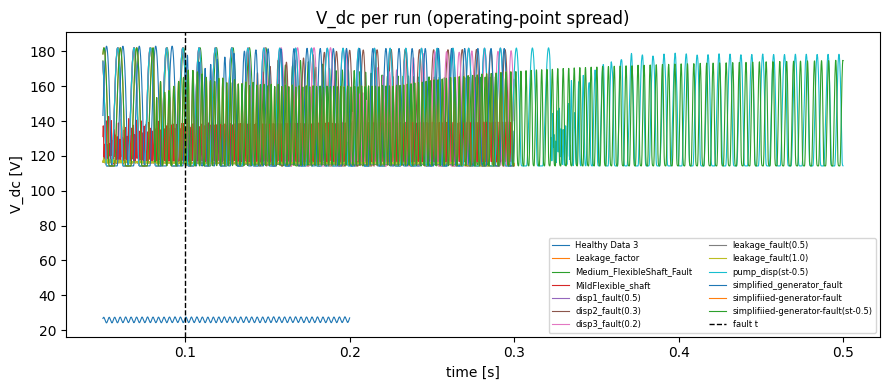

In [10]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4))
for rid, g in clean_all.groupby("run_id"):
    ax.plot(g["time"], g["vdc"], label=rid, lw=0.8)
ax.axvline(P.FAULT_T, color="k", ls="--", lw=1, label="fault t")
ax.set(xlabel="time [s]", ylabel="V_dc [V]", title="V_dc per run (operating-point spread)")
ax.legend(fontsize=6, ncol=2); plt.tight_layout(); plt.show()